In [1]:
import lightkurve
from lightkurve import DesignMatrix, RegressionCorrector
import matplotlib.pyplot as plot
import numpy
%matplotlib inline
plot.style.use('finny_style.mplstyle')

In [2]:
star_id = 295440174
star_id = f'TIC {star_id}'

In [3]:
search_result = lightkurve.search_targetpixelfile(star_id, mission = 'TESS', cadence = 'long')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 09,2019,TESS-SPOC,1800,295440174,0.0
1,TESS Sector 10,2019,TESS-SPOC,1800,295440174,0.0
2,TESS Sector 35,2021,TESS-SPOC,600,295440174,0.0
3,TESS Sector 36,2021,TESS-SPOC,600,295440174,0.0
4,TESS Sector 62,2023,TESS-SPOC,200,295440174,0.0
5,TESS Sector 63,2023,TESS-SPOC,200,295440174,0.0


In [4]:
pixel_file = search_result[-1].download()
pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
pixel_file

TessTargetPixelFile(TICID: 295440174)

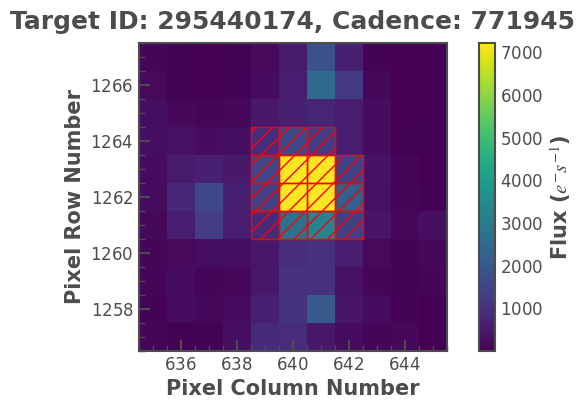

In [5]:
#for pixel_file in pixel_files:
aperture_mask = pixel_file.pipeline_mask
pixel_file.plot(aperture_mask = aperture_mask)

plot.show()

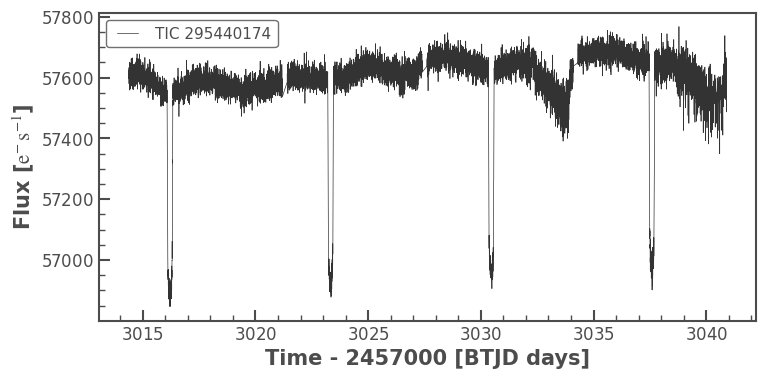

In [6]:
uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)
uncorrected_lc.plot()
plot.show()

In [7]:
regressors = pixel_file.flux[:, ~aperture_mask]
regressors.shape

(10942, 106)

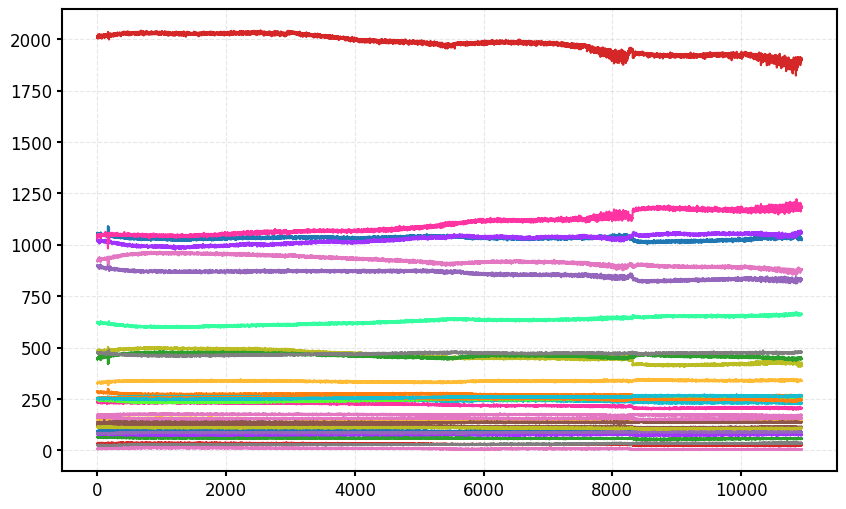

In [8]:
plot.plot(regressors[:, :30])
plot.show()

In [9]:
design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask], name = f'{star_id} regressors')
design_matrix

TIC 295440174 regressors DesignMatrix (10942, 106)

In [10]:
design_matrix = design_matrix.pca(5)
design_matrix = design_matrix.append_constant()
design_matrix

TIC 295440174 regressors DesignMatrix (10942, 6)

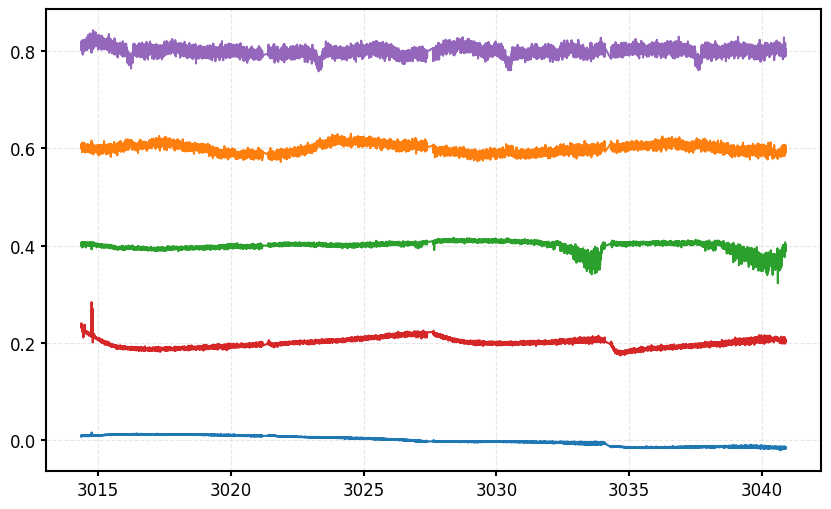

In [11]:
plot.plot(pixel_file.time.value, design_matrix.values[:, :5] + (numpy.arange(5) * 0.2))
plot.show()

In [12]:
corrector = RegressionCorrector(uncorrected_lc)
corrector

RegressionCorrector (ID: 295440174)

In [13]:
lc = corrector.correct(design_matrix)
lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float64,float64,float64,float64,int32,int32
3014.3717027979924,57610.92903861332,20.498992895183825,640.5585761709267,1262.3003689179013,771945,0
3014.3740176264196,57630.45509050437,20.498399625508114,640.5537166594116,1262.2930824125417,771946,0
3014.3763324548468,57604.214297654595,20.50206392644752,640.557251366823,1262.2991429187084,771947,0
3014.3786472832753,57626.22514840087,20.504211737460412,640.5557357679411,1262.2965302341372,771948,0
3014.380962111704,57638.676388898304,20.50438885112656,640.5574949002445,1262.2990660401492,771949,0
3014.383276940131,57612.96421201361,20.503484662388033,640.5580440534238,1262.298963837771,771950,0
3014.385591768792,57623.57948355347,20.49973873809318,640.555843534446,1262.2937901884209,771951,0
3014.38790659722,57602.93361834512,20.498703334086922,640.5577654166458,1262.3005646300958,771952,0


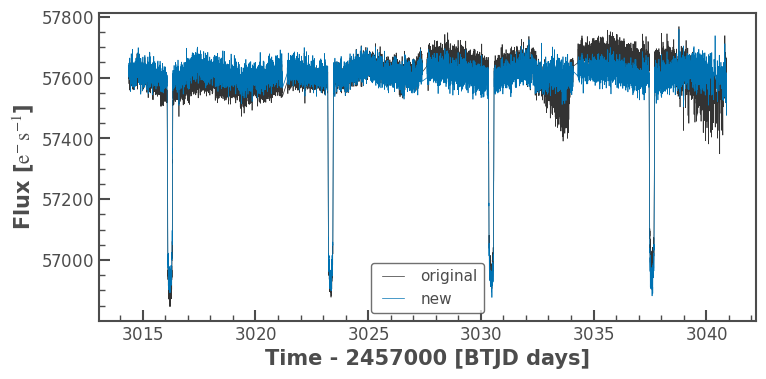

In [14]:
ax = uncorrected_lc.plot(label = 'original')
lc.plot(ax = ax, label = 'new')
plot.show()

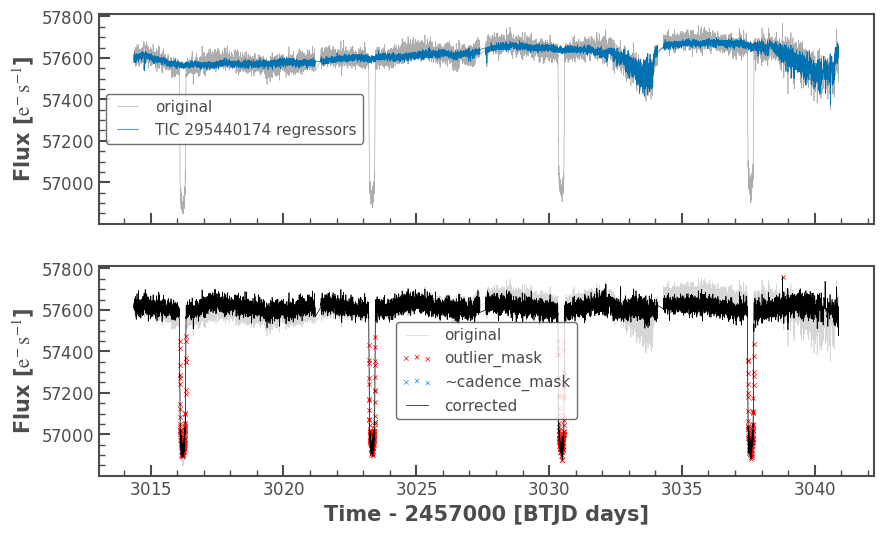

In [15]:
corrector.diagnose()
plot.show()

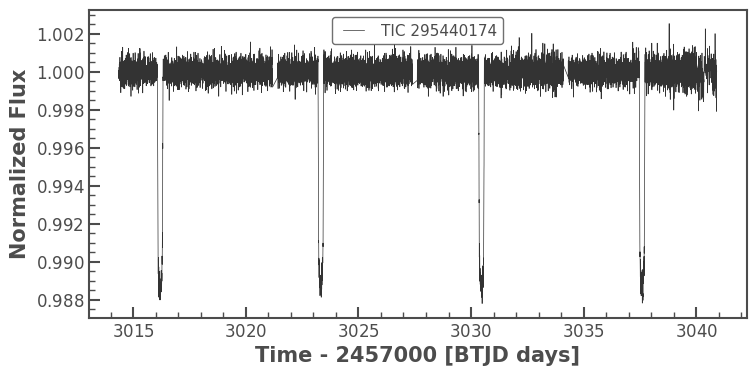

In [16]:
_lc = lc.flatten(break_tolerance = 10, niters = 10)#.remove_outliers(sigma = 10.0)
_lc.plot()
plot.show()

In [17]:
pixel_files = search_result.download_all()

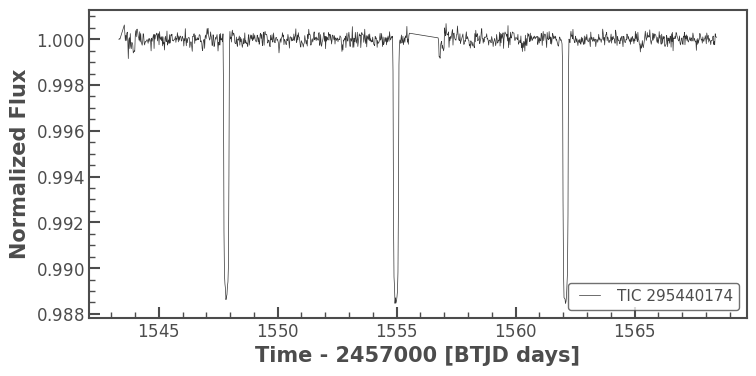

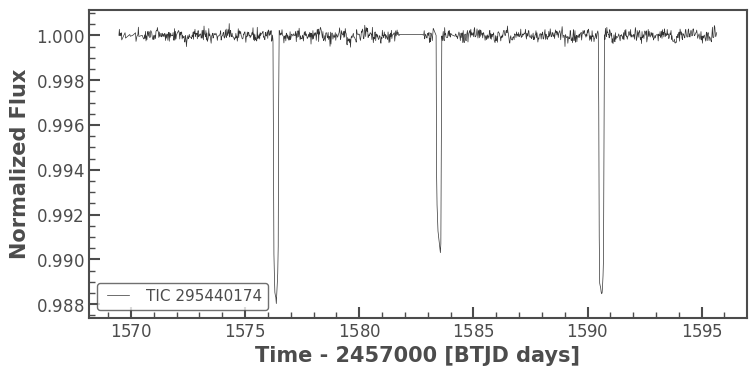

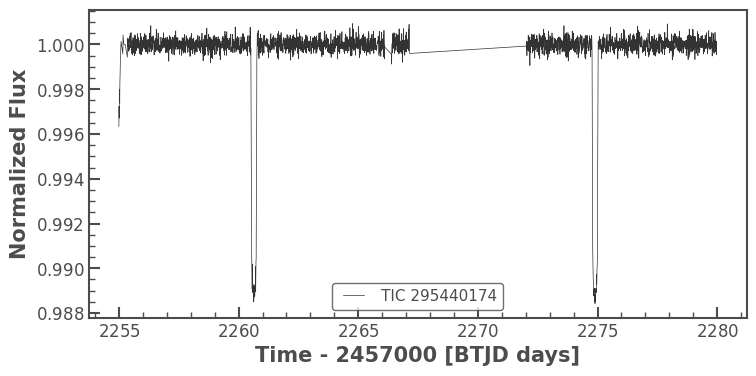

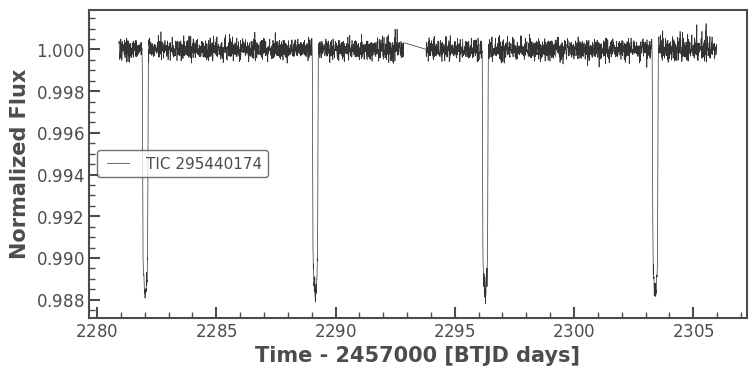

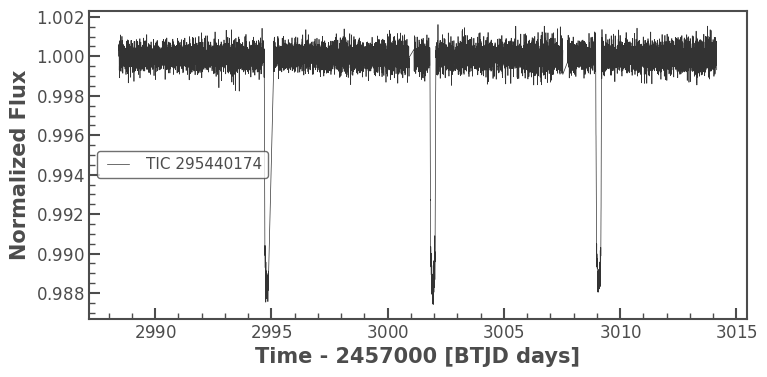

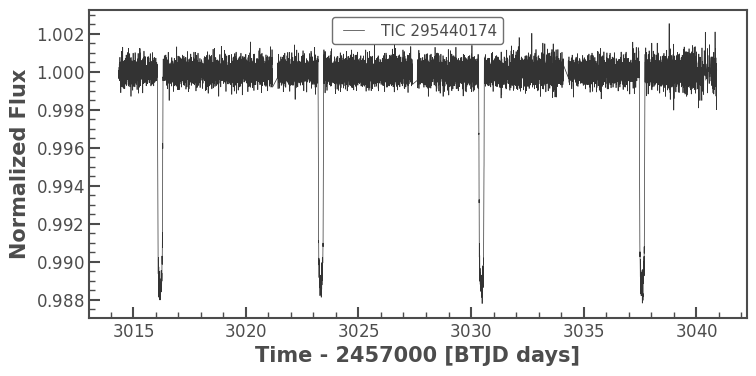

In [18]:
collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    aperture_mask = pixel_file.pipeline_mask
    # aperture_mask = pixel_file.create_threshold_mask(threshold = 10, reference_pixel = 'center')
    uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)

    design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask]).pca(5).append_constant()
    lc = RegressionCorrector(uncorrected_lc).correct(design_matrix)
    # lc = uncorrected_lc
    lc = lc.normalize().flatten(niters = 10).remove_outliers(10.0)
    lc.plot()
    collection.append(lc)

plot.show()

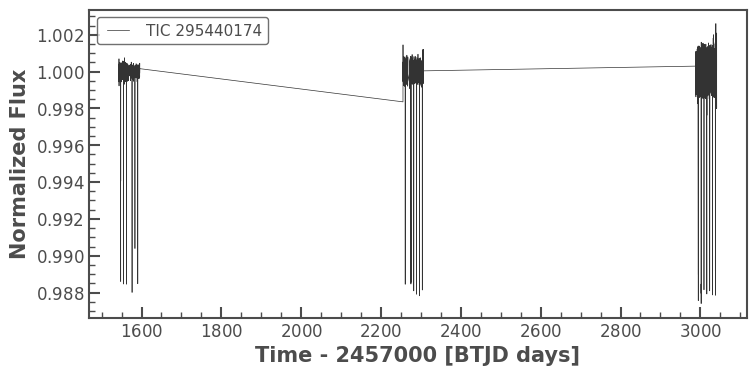

In [19]:
lc = collection[:].stitch()
lc = lc.flatten(break_tolerance = 10, niters = 10).remove_outliers(sigma = 10.0)
lc.plot()
plot.show()

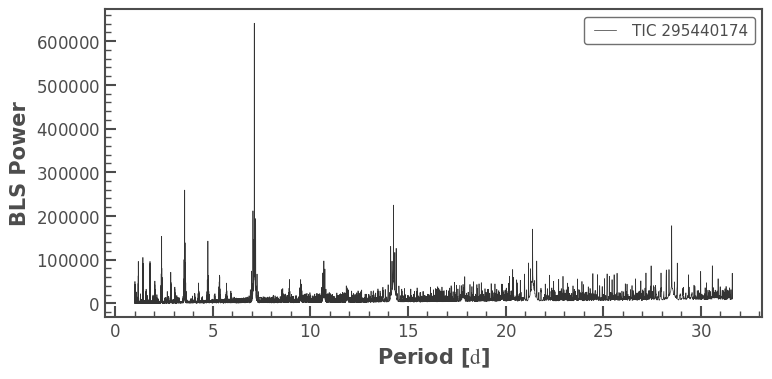

In [20]:
periods = numpy.logspace(0, 1.5, 10 ** 4, base = 10.0)
periodogram = lc.to_periodogram(method = 'boxleastsquares', period = periods, frequency_factor = 10 ** 6)
periodogram.plot()
plot.show()

In [21]:
period = periodogram.period_at_max_power
transit_time = periodogram.transit_time_at_max_power
transit_duration = periodogram.duration_at_max_power
transit_duration = 1

period, transit_time, transit_duration

(<Quantity 7.12828899 d>,
 <Time object: scale='tdb' format='btjd' value=1547.8059384044943>,
 1)

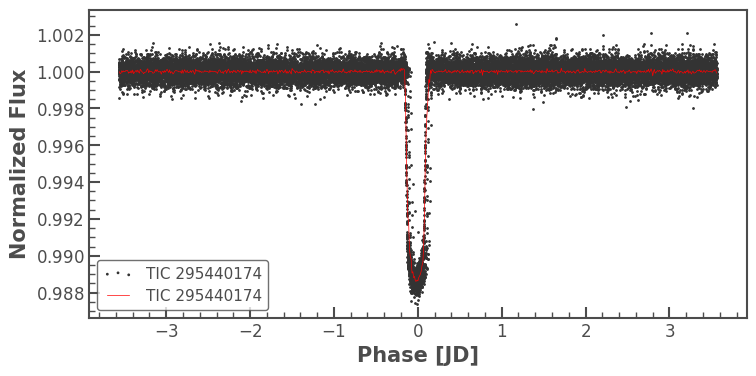

0.011387180782750583

In [22]:
folded_lc = lc.fold(period = period, epoch_time = transit_time)
binned_lc = folded_lc.bin(time_bin_size = 0.01)
ax = folded_lc.scatter()
binned_lc.plot(ax = ax, c = 'r')
d = 1
# ax.set_xlim(-d, d)
# ax.set_ylim(0.995, 1.0025)
plot.show()
1 - numpy.nanmin(binned_lc.flux.value)

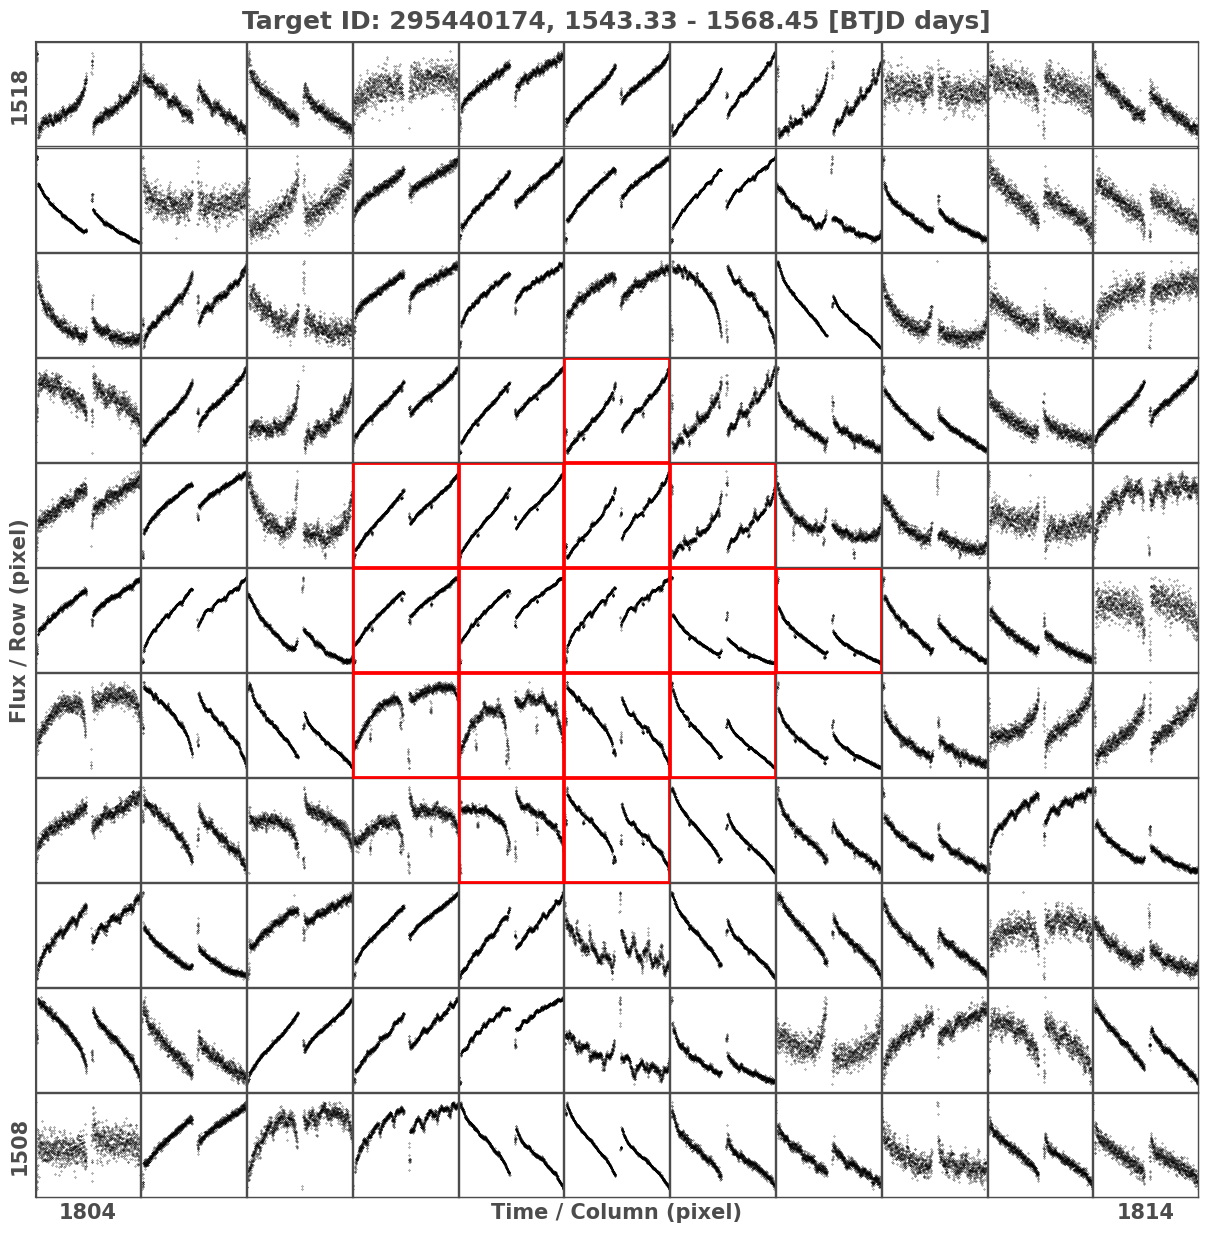

In [23]:
pixel_file = pixel_files[0]
pixel_file.plot_pixels(aperture_mask = pixel_file.pipeline_mask)
plot.show()

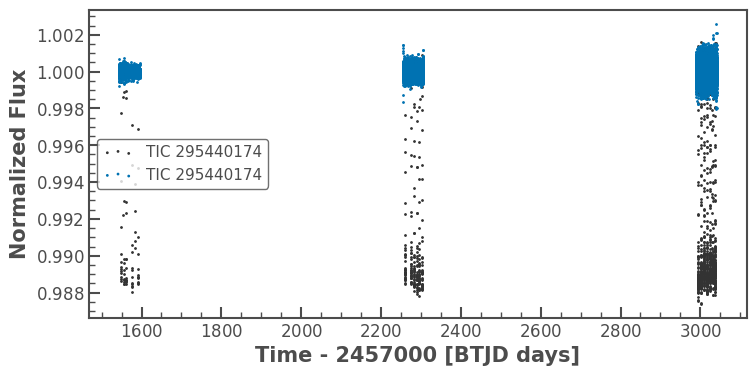

In [24]:
mask = periodogram.get_transit_mask(
            period = period,
            transit_time = transit_time,
            duration = transit_duration
        )

lc_mask = lc[mask]
ax = lc_mask.scatter()
lc = lc[~mask]
lc.scatter(ax = ax)
plot.show()